# 08 · Agent that can self-verify

Notebook 07 plus one ability: **the model sees the figures it makes and checks its own work before answering.**
Everything else (store, sandbox, history, tools, skills, `ask()`) is unchanged.

### What is new

| where | change |
|---|---|
| `run_python` (section 4) | every PNG the cell saves comes back **inside the tool result** as an image, after its file name; at most `MAX_IMAGES_PER_CALL` per cell |
| `view_figure` (section 4) | new tool: look at a PNG from an earlier question. The model is told not to use it for figures it just made (those arrive by themselves) |
| skill `figures` (section 5) | when a figure earns its place (not every answer), that it is made **last** from checked numbers, and what it must contain (plotted period in the title, n on the points, n = 1 without error bar, gaps not zeros) |
| skill `self_check` (section 5) | the order numbers → figure → figure read-back → answer; the read-back writes down what the model sees on the image (max, min, where) and compares it with the checked table; fix, don't explain away |
| rules (section 6) | the *Figures* bullet: a figure only when warranted, last, read back before answering; `view_figure` only when a question depends on an old figure |
| output validator (section 7) | an answer that names a file which does not exist in /workspace is sent back to the model (`ModelRetry`) |
| store (section 8) | image bytes are **not** stored in SQLite: the file is on disk, the trace keeps the `[image: name, WxH px, ≈N tokens]` line |
| tokens (section 10) | `calls_table` adds `images` and `image_tokens_est` per model call |
| sandbox `exec_server.py` | a file **overwritten** by a cell (same name) is reported again under `figures saved` / `files written`, so a corrected figure is shown to the model too; before, only new names were reported (image rebuilt 2026-09-30) |

**Image tokens.** Mantle does not report image tokens separately (`usage.details` has only `reasoning_tokens`), so
the notebook *estimates* them from the pixel size with a fit measured on GPT-5.6 Luna on 2026-09-30
(600×350 px → 353, 1000×500 → 656, 1200×600 → 866, 1600×800 → 1394 tokens; ≈ 190 + 0.94 per 1000 px).
The estimate is written into the `[image: ...]` line the model sees, so it survives in the stored trace.
An image is re-sent with every later call of the same question (that is how the context works) and it is **not**
served from the cache: measured on 2026-09-30, image tokens stay uncached in every placement (tool result, user
message, explicit breakpoint on the image), while the same amount of text caches fully. So an image costs full
price on every call it sits in — the reason the rules make a figure the last step, so it is read once or twice.

### Where the model sees an image

| situation | how |
|---|---|
| the cell it just ran saved a PNG | automatically, inside that `run_python` result (this question only) |
| a follow-up question about a figure from an earlier turn | it calls `view_figure(name)`; earlier turns' answers name their files |
| you ask "look at gsfc_climatology.png and ..." | same: `view_figure`, the file name is in the recent history |
| a figure it already looked at in this question | never again: the image is still in its context |

### How the model "remembers"

**It doesn't.** The model keeps nothing between questions. Before every question this notebook rebuilds its whole
context from two places:

| source | holds | survives a sandbox stop? | survives closing the notebook? |
|---|---|---|---|
| **SQLite** file `agent_turns.sqlite` | the **past**: every question, answer, what each turn did, tokens, cost | yes | yes (it is a file) |
| **the sandbox** (docker container) | the **present**: variables in memory, files in `/workspace` | variables **no**, files yes | variables no, files yes |

What the model receives for question N:

```
system prompt                                    (rules, data dictionary, skills — always the same)
question of turn N-5  →  answer + "[this turn did] tools: run_python×3 | files: x.csv"  ┐ from SQLite:
...                                                                                     │ the last KEEP_TURNS
question of turn N-1  →  answer + "[this turn did] ..."                                 ┘ finished turns
### sandbox state now      ← asked from the sandbox right now: variables (+ their meaning), files, memory
### question               ← the new question
```

Three situations, same code path:

| situation | from SQLite | from the sandbox |
|---|---|---|
| **next question** | last 5 turns | variables still there, each with its meaning |
| **sandbox stopped** (60 idle min, out of memory, `sb.stop`) | last 5 turns, unchanged | a fresh sandbox: *"kernel: restarted (reason)"*, no variables, files from the last 5 turns |
| **tomorrow** (notebook closed) | run the cells again with the same `CONVERSATION_ID`: last 5 turns come back from the file | the container stopped after 60 idle min → same as the row above |

How the notebook knows the sandbox restarted: every sandbox start is a new docker container with a **new id**,
and every turn stores the id it ran on. Id now ≠ id of the last turn → restarted.

### What `await ask(question)` does

1. **Budget** — stop if the conversation already spent `CONV_COST_LIMIT` dollars.
2. **Build the context** — start the sandbox if needed, then history from SQLite + state block from the sandbox.
3. **Run** — the agent loop, every step printed, stopped by `LIMITS` if it runs too long.
4. **Store** — one row in SQLite: question, answer, variables kept, sandbox id, full message trace, tokens, cost.
5. **Kernel cleanup** — delete every variable no recent turn asked to keep.

Sections: 1 Store (SQLite) · 2 Sandbox and its variables · 3 What the model sees · 4 Tools · 5 Skills ·
6 System prompt · 7 Model and agent · 8 `ask()` · 9 Try it · 10 Check the tokens · 11 Resume tomorrow · 12 Cleanup

In [45]:
import json, os, re, sqlite3, subprocess, sys
from collections import Counter
from datetime import datetime, timezone
os.environ["PYDANTIC_AI_NO_BANNER"] = "1"
from IPython.display import Image, Markdown, display
import pandas as pd
import pyarrow.parquet as pq

sys.path.insert(0, "../sandbox")
import sandbox as sb

CONVERSATION_ID = "conv_012"                              # container name + folder conversation_data/conv_010/
KEEP_TURNS      = 5                                       # finished turns the model sees
CONV_COST_LIMIT = None                                    # USD for the whole conversation; None = no limit
DB_FILE         = sb.CONV_DIR / "agent_turns.sqlite"      # notebook 06 keeps its own conversations.sqlite
WORKSPACE       = sb.CONV_DIR / CONVERSATION_ID           # the sandbox's /workspace, seen from this machine
SHOW_FIGURES    = True                                    # False = the model never sees images (text-only models, ablation)
MAX_IMAGES_PER_CALL = 4                                   # PNGs attached to one run_python result; the rest are named only

## 1 · Store

One SQLite file, one table `turns`, **one row per question**. This file is the conversation's long-term memory:
it is written once at the end of every question and read at the start of the next one. There are only three SQL
statements in the whole notebook: create the table, insert a row, select all rows of this conversation. Everything
else is plain Python on that list of rows.

- `all_turns()`: every row, oldest first, stopped turns included (for cost and the last sandbox id).
- `recent_turns()`: the last `KEEP_TURNS` rows with `status = 'ok'`. **Only these ever reach the model.**

**Tokens.** Pydantic AI adds up every model call of the turn. Its `input_tokens` is *everything* sent to the model,
cached or not, so the parts add up exactly:

```
input_tokens  = uncached_input + cache_read + cache_write
output_tokens = visible text and tool calls + reasoning_tokens
```

`reasoning_tokens` is NULL when the provider does not report it. Section 10 re-adds the tokens call by call from the
stored messages and checks they match this row — it stays the check when the self-verification step arrives.

In [46]:
DB = sqlite3.connect(DB_FILE)
DB.row_factory = sqlite3.Row          # a row behaves like a dict: row["question"]

DB.execute("""
CREATE TABLE IF NOT EXISTS turns (
    conversation     TEXT,
    turn             INTEGER,  -- 1, 2, 3 ... within the conversation
    asked            TEXT,     -- UTC time of the question
    status           TEXT,     -- ok | stopped (a usage limit ended the turn)
    question         TEXT,
    answer           TEXT,     -- NULL when stopped
    summary          TEXT,     -- one line: tools used, files written (read off the tool calls, no model)
    variables        TEXT,     -- JSON list of {name, meaning}: what the model kept in the kernel
    sandbox          TEXT,     -- id of the docker container the turn ran on (new id = sandbox restarted)
    restart_note     TEXT,     -- what the model was told about a restart before this turn, else NULL
    requests         INTEGER,  -- model calls
    tool_calls       INTEGER,  -- tool executions
    input_tokens     INTEGER,  -- all input  = uncached_input + cache_read + cache_write
    uncached_input   INTEGER,
    cache_read       INTEGER,
    cache_write      INTEGER,
    output_tokens    INTEGER,  -- all output, reasoning included
    reasoning_tokens INTEGER,  -- part of output_tokens; NULL if not reported
    cost_usd         REAL,
    messages         TEXT,     -- the full trace: every message of the turn as Pydantic AI JSON
    PRIMARY KEY (conversation, turn)
)""")


def all_turns():
    """Every stored turn of this conversation, oldest first."""
    return DB.execute("SELECT * FROM turns WHERE conversation = ? ORDER BY turn", (CONVERSATION_ID,)).fetchall()


def recent_turns():
    """The last KEEP_TURNS turns that finished (status ok). Stopped turns are never shown to the model."""
    finished = [t for t in all_turns() if t["status"] == "ok"]
    return finished[-KEEP_TURNS:]


def save_turn(row):
    """row = {column: value}. Adds the conversation id and the next turn number, inserts it, returns the number."""
    row = {"conversation": CONVERSATION_ID, "turn": len(all_turns()) + 1, **row}
    columns = ", ".join(row.keys())
    placeholders = ", ".join(["?"] * len(row))
    DB.execute(f"INSERT INTO turns ({columns}) VALUES ({placeholders})", list(row.values()))
    DB.commit()
    return row["turn"]


def token_columns(usage):
    """Pydantic AI usage (of a whole turn, or of one model call) -> the token and cost columns of the table."""
    return {
        "input_tokens":     usage.input_tokens,
        "uncached_input":   usage.input_tokens - usage.cache_read_tokens - usage.cache_write_tokens,
        "cache_read":       usage.cache_read_tokens,
        "cache_write":      usage.cache_write_tokens,
        "output_tokens":    usage.output_tokens,
        "reasoning_tokens": usage.details.get("reasoning_tokens"),      # None if not reported
        "cost_usd":         float(usage.cost) if usage.cost is not None else None,
    }


def conversation_cost():
    """USD spent so far in this conversation, stopped turns included."""
    total = 0.0
    for t in all_turns():
        total += t["cost_usd"] or 0
    return total


def show_turns():
    """The table without the long columns (answer, messages)."""
    columns = ["turn", "asked", "status", "question", "summary", "variables", "sandbox", "restart_note",
               "requests", "tool_calls", "input_tokens", "uncached_input", "cache_read", "cache_write",
               "output_tokens", "reasoning_tokens", "cost_usd"]
    rows = [{c: t[c] for c in columns} for t in all_turns()]
    return pd.DataFrame(rows, columns=columns)

In [47]:
show_turns()

,turn,asked,status,question,summary,variables,sandbox,restart_note,requests,tool_calls,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd


## 2 · Sandbox and its variables

This is the "memory" part. Three facts drive all of it:

- **Variables live in the sandbox, files live on disk.** When the sandbox stops (60 idle minutes, memory or storage
  limit, `sb.stop`) every variable is gone; the files in `/workspace` stay.
- **Every start of the sandbox is a new docker container with a new id.** Each turn stores the id it ran on
  (`sandbox` column). So *"did the sandbox restart since the last turn?"* is just *"is the id different now?"* —
  and only turns with the **current** id can have left variables behind.
- **The model says which variables to keep.** Every answer ends with `kept_variables` (name + one-line meaning).
  After each turn, the variables named by any of the recent turns on this sandbox stay, all others are deleted.

Example with `KEEP_TURNS = 5`:

| after turn | model kept | in the kernel afterwards | why |
|---|---|---|---|
| 1 | `gsfc_daily` | `gsfc_daily` | temporaries of turn 1 deleted |
| 2 | `gsfc_annual` | `gsfc_daily`, `gsfc_annual` | turn 1 still recent |
| 3 | nothing | `gsfc_daily`, `gsfc_annual` | turns 1, 2 still recent |
| 6 | nothing | `gsfc_annual` | turn 1 left the window of 5, so `gsfc_daily` goes |
| sandbox stops | | nothing | new container, new id |
| 7 | | | state block says *restarted*; turns 1–6 still shown as question → answer |

Before every question `state_block()` asks the sandbox what it holds **now** and writes it on top of the question:
each variable with its type from the sandbox and its meaning from `kept_variables` (a variable nobody described shows
*not described*), the files, memory and storage.

In [48]:
LAST_STOP_REASON = "unknown"      # why the sandbox was last found stopped; only used in the restart note


def sandbox_id():
    """Short docker id of the running sandbox, "" if none. Changes on every start."""
    out = subprocess.run(["docker", "ps", "-q", "--filter", f"name=^{CONVERSATION_ID}$"],
                         capture_output=True, text=True)
    return out.stdout.strip()


def start_sandbox_if_needed():
    """Start the sandbox when it is not running, remembering why the previous one stopped."""
    global LAST_STOP_REASON
    if sb.running(CONVERSATION_ID):
        return
    killed_file = WORKSPACE / "_killed.txt"          # the sandbox writes its reason here when it stops itself
    if killed_file.exists():
        LAST_STOP_REASON = killed_file.read_text().strip()
    else:
        LAST_STOP_REASON = "no reason recorded: memory limit, host restart or stopped by hand"
    sb.start(CONVERSATION_ID)                          # deletes _killed.txt, so it is read first


def sandbox_restarted():
    """True when the last stored turn ran on another sandbox than the one up now."""
    turns = all_turns()
    if not turns:
        return False                                   # first question: nothing to have lost
    return turns[-1]["sandbox"] != sandbox_id()


def variable_meanings():
    """{name: meaning} from kept_variables of the recent turns that ran on the sandbox up now; later turns win."""
    current = sandbox_id()
    meanings = {}
    for t in recent_turns():
        if t["sandbox"] != current:
            continue                                   # ran on an older sandbox: its variables are gone; if a sandbox restarted, all variables are gone so we don't really need their meanings.
        for v in json.loads(t["variables"]):
            meanings[v["name"]] = v["meaning"]
    return meanings


def state_block(restart_note=None):
    """The text put on top of every question: what the sandbox holds right now."""
    state = sb.state(CONVERSATION_ID)
    meanings = variable_meanings()
    lines = ["### sandbox state now"]

    if restart_note:
        lines.append(f"kernel: {restart_note}")

    if state["vars"]:
        lines.append("variables (name: type — what it holds):")
        for name, vtype in state["vars"].items():
            lines.append(f"  {name}: {vtype} — {meanings.get(name, 'not described')}")
    else:
        lines.append("variables: none")

    # # only the files the recent turns produced (their answers explain them), restart or not
    # recent_summaries = " ".join(t["summary"] for t in recent_turns())
    # recent_files = [f for f in state["files"] if f in recent_summaries]
    # lines.append("files from recent turns: " + (", ".join(recent_files) or "none"))

    lines.append(f"memory used: {state['rss_mb']} of {state['memory_limit_mb']} MB; "
                 f"storage used: {state['workspace_mb']} of {state['workspace_cap_mb']} MB in /workspace")
    return "\n".join(lines)


RELEASE_MEMORY = """%reset -f out
__import__('gc').collect()
__import__('pyarrow').default_memory_pool().release_unused()
__import__('ctypes').CDLL('libc.so.6').malloc_trim(0)"""


def cleanup_kernel():
    """After a finished turn: keep the variables recent turns named in kept_variables, delete the rest."""
    keep = variable_meanings()
    live = sb.state(CONVERSATION_ID)["vars"]
    kept    = [name for name in live if name in keep]
    deleted = [name for name in live if name not in keep]
    # del + gc alone give nothing back to the OS (measured 2026-09-30: 636 MB before and after). Three more steps
    # bring a turn back to ~280 MB: IPython's Out cache holds every value a cell returned as its last expression,
    # pyarrow's pool keeps freed buffers for reuse, and libc keeps its arenas. __import__(...) instead of import,
    # so no new variable appears in the kernel.
    code = ("del " + ", ".join(deleted) + "\n" if deleted else "") + RELEASE_MEMORY
    sb.exec_code(CONVERSATION_ID, code)
    return kept, deleted

In [49]:
start_sandbox_if_needed()
print("sandbox id:", sandbox_id(), "| restarted since the last turn:", sandbox_restarted())
print(state_block())

sandbox id: cde236003335 | restarted since the last turn: False
### sandbox state now
variables: none
memory used: 201 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace


In [50]:
variable_meanings()

{}

In [51]:
cleanup_kernel()

([], [])

## 3 · What the model sees

Everything the model gets for a question is built here, from SQLite (sections 1) and the sandbox (section 2).

**History.** `history_for_model()` turns each of the `recent_turns()` into two messages: the question, and the answer
with one extra line `[this turn did] tools: run_python×3 | files: x.csv`. Old tool calls and tool outputs are
**not** sent again: the full trace stays in the `messages` column for you, the model only gets the gist. The
`[this turn did]` line is written by `turn_summary()` from the turn's own tool calls, no model involved. Variables are
not in it, because the state block says what exists *now*.

**The new question.** `build_context(question)` starts the sandbox if needed, decides whether to add the restart
note (sandbox id now ≠ sandbox id of the last turn), and puts the state block on top of the question.

`preview_context(question)` prints exactly that, without calling the model. Run it any time — after `sb.stop`, or
tomorrow after reopening the notebook — to see what the model would get.

In [52]:
from pydantic_ai.messages import (ModelMessagesTypeAdapter, ModelRequest, ModelResponse, UserPromptPart, TextPart,
                                  ThinkingPart, ToolCallPart, ToolReturnPart, RetryPromptPart, CachePoint)


# def history_for_model():
#     """The recent finished turns from SQLite, as question -> answer message pairs."""
#     history = []
#     for t in recent_turns():
#         history.append(ModelRequest(parts=[UserPromptPart(content=t["question"])]))
#         history.append(ModelResponse(parts=[TextPart(content=f"{t['answer']}\n\n[this turn did] {t['summary']}")]))
#     return history


def history_for_model():
    """The recent finished turns from SQLite, as question -> answer message pairs.
    Files a turn wrote that are no longer in /workspace are marked "(deleted since)"."""
    # a fixed first message ending in a cache breakpoint: system prompt + tools + this line are the same for
    # every question, so from the second question on they are read from the cache instead of sent again
    history = [ModelRequest(parts=[UserPromptPart(content=["Conversation so far:", CachePoint()])])]
    for t in recent_turns():
        summary = t["summary"]                              # "tools: run_python×2 | files: a.csv, b.png"
        if " | files: " in summary:
            tools_part, files_part = summary.split(" | files: ")
            files = []
            for name in files_part.split(", "):
                if (WORKSPACE / name).exists():             # the sandbox's /workspace is this folder on the host
                    files.append(name)
                else:
                    files.append(f"{name} (deleted since)")
            summary = tools_part + " | files: " + ", ".join(files)
        history.append(ModelRequest(parts=[UserPromptPart(content=t["question"])]))
        history.append(ModelResponse(parts=[TextPart(content=f"{t['answer']}\n\n[this turn did] {summary}")]))
    return history

def build_context(question):
    """(history, prompt, restart_note) for the next question."""
    start_sandbox_if_needed()
    restart_note = None
    if sandbox_restarted():
        restart_note = f"restarted ({LAST_STOP_REASON}); every earlier variable is gone, files in /workspace are kept"
    history = history_for_model()
    prompt = state_block(restart_note) + "\n\n### question\n" + question
    return history, prompt, restart_note


def preview_context(question="(next question)"):
    """Print what the model would receive for this question (system prompt left out). Calls no model."""
    history, prompt, _ = build_context(question)
    for message in history:
        for part in message.parts:
            who = "USER " if isinstance(message, ModelRequest) else "MODEL"
            print(f"--- {who}: {part.content}\n")
    print(f"--- USER (new):\n{prompt}")


def tool_text(part):
    """The text of a tool result. With images the content is a list: text items and BinaryImage items;
    only the text is joined, the images are skipped."""
    if isinstance(part.content, str):
        return part.content
    texts = []
    for item in part.content:
        if isinstance(item, str):
            texts.append(item)
    return "\n".join(texts)


def names_after(text, prefix):
    """Names listed on the lines of a run_python result that start with prefix, e.g. 'figures saved: '.
    Only names that exist in /workspace count: the model's own print() output is in the same text and
    may contain a line like 'figures saved: none'."""
    names = []
    for line in text.splitlines():
        if line.startswith(prefix):
            for name in line[len(prefix):].split(", "):
                if (WORKSPACE / name).exists():
                    names.append(name)
    return names


def turn_summary(messages):
    """The [this turn did] line: which tools ran how often, which files were written."""
    tool_counts = Counter()
    files = []
    for message in messages:
        for part in message.parts:
            if isinstance(part, ToolCallPart) and part.tool_name != "final_result":
                tool_counts[part.tool_name] += 1
            if isinstance(part, ToolReturnPart) and part.tool_name == "run_python":
                files += names_after(tool_text(part), "figures saved: ")
                files += names_after(tool_text(part), "files written: ")
    tools_text = ", ".join(f"{name}×{n}" for name, n in tool_counts.items())
    summary = "tools: " + (tools_text or "none")
    if files:
        unique_files = list(dict.fromkeys(files))          # drop repeats, keep order
        summary += " | files: " + ", ".join(unique_files)
    return summary

In [53]:
build_context("WEll this is my next question")

([ModelRequest(parts=[UserPromptPart(content=['Conversation so far:', CachePoint(kind='cache-point', ttl='5m')], timestamp=datetime.datetime(2026, 9, 30, 16, 43, 57, 346667, tzinfo=datetime.timezone.utc))])],
 '### sandbox state now\nvariables: none\nmemory used: 201 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace\n\n### question\nWEll this is my next question',
 None)

In [54]:
preview_context()

--- USER : ['Conversation so far:', CachePoint(kind='cache-point', ttl='5m')]

--- USER (new):
### sandbox state now
variables: none
memory used: 201 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
(next question)


## 4 · Tools

The five tools of notebook 07 plus `view_figure`. Two changes:

- `run_python` returns a **list** when the cell saved PNGs: the usual text, then for each PNG one line
  `[image: name, WxH px, ≈N tokens]` followed by the image itself. Pydantic AI sends the image inside the tool
  result (verified on Luna via Mantle: the model reads it). At most `MAX_IMAGES_PER_CALL` images per cell; the
  others are named so the model can `view_figure` one if it needs to.
- `view_figure(name)` returns one PNG from /workspace the same way. Its docstring tells the model when not to use it.

`image_for_model(name)` builds the label line + image pair for both tools; the token estimate is the pixel fit from the top.


In [55]:
from PIL import Image as PILImage
from pydantic_ai.messages import BinaryImage


def image_for_model(name):
    """One PNG from /workspace as the model receives it: a label line, then the image itself."""
    path = WORKSPACE / name
    width, height = PILImage.open(path).size
    tokens = int(190 + 0.94 * width * height / 1000)      # fitted on Luna 2026-09-30; the API does not report image tokens
    label = f"[image: {name}, {width}x{height} px, ≈{tokens} tokens]"
    return [label, BinaryImage.from_path(path)]


def run_python(code: str, timeout: int = 60) -> str | list:
    '''Run Python code in this conversation's sandbox (a persistent IPython kernel) and return what happened.
    Pre-imported: numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns.
    DATA = path of the AERONET AOD Level 2 daily parquet (read-only; Always read a column subset, the full table is ~1 GB; The system where the code executes is very lightweight).
    Variables persist between calls. No network. 2 GB RAM, 2 CPUs.
    What comes back, like a notebook cell:
    - stdout: everything you print(); stderr: warnings.
    - result: the value of the last expression if it is not an assignment (a DataFrame comes back as shape, dtypes,
      head and tail). Assign to a variable to suppress it.
    - stdout, stderr and result are each cut to 4000 characters (middle removed, marked "[N chars clipped]").
      Show only what you need: a small slice, .to_string() on a few rows, or aggregate first. Never print a whole
      table; save it as CSV under /workspace/ and report the file name.
    - Figures: save them yourself with fig.savefig('/workspace/<descriptive_name>.png'); any figure left open is
      auto-saved as fig_NNN.png. No plt.show(). All PNG names written by the cell are returned under figures,
      and the images themselves are shown to you right after (the first 4 per call): look at them for double checking or verification.
    - new/changed variables with type and shape, files written, elapsed time and memory.
    Write any export (parquet, csv, png) under /workspace/.'''
    start_sandbox_if_needed()
    r = sb.exec_code(CONVERSATION_ID, code, timeout)
    out = []
    if r.get("stdout"):       out.append("stdout:\n" + r["stdout"].rstrip())
    if r.get("stderr"):       out.append("stderr:\n" + r["stderr"].rstrip())
    if r.get("error"):        out.append("ERROR: " + r["error"])
    if r.get("result"):       out.append("result:\n" + r["result"])
    if r.get("figures"):      out.append("figures saved: " + ", ".join(r["figures"]))
    if r.get("new_files"):    out.append("files written: " + ", ".join(r["new_files"]))
    if r.get("vars_new"):     out.append(f"new variables: {r['vars_new']}")
    if r.get("vars_changed"): out.append(f"changed variables: {r['vars_changed']}")
    if "elapsed_s" in r:      out.append(f"[{r['elapsed_s']} s | memory used {r['rss_mb']} of {r.get('memory_limit_mb')} MB]")
    text = "\n".join(out) or "(no output)"

    figures = r.get("figures") or []
    if not SHOW_FIGURES or not figures:
        return text

    # the text, then the images the cell saved (at most MAX_IMAGES_PER_CALL): the model sees them in this result
    content = [text]
    for name in figures[:MAX_IMAGES_PER_CALL]:
        content += image_for_model(name)
    not_shown = figures[MAX_IMAGES_PER_CALL:]
    if not_shown:
        content.append(f"[{len(not_shown)} more figures saved but not shown: {', '.join(not_shown)}; view_figure(name) shows one]")
    return content


def view_figure(name: str) -> str | list:
    '''Look at one PNG from /workspace, e.g. a figure made in an earlier question (earlier answers name their files).
    Do NOT use it for figures made in this question: every run_python result already shows you the PNGs it saved,
    and once you have seen an image it stays in front of you. Use it only when the question depends on what an
    older figure shows and the earlier answer does not already say it. Each image costs a few hundred tokens.'''
    if not SHOW_FIGURES:
        return "images are switched off in this run; describe the figure from the earlier answer instead"
    name = name.replace("sandbox:", "").replace("/workspace/", "")    # accept the full path too
    if not name.lower().endswith(".png"):
        return f"{name}: only PNG files can be viewed"
    if not (WORKSPACE / name).exists():
        # return f"{name}: not found in /workspace (deleted since)"
        return f"{name}: no such file in /workspace (check the name in the earlier answer). The file could also have been deleted! or maybe check the spelling of the name."
    
    return image_for_model(name)


def kernel_state() -> str:
    '''Variables (type and shape), files in /workspace and memory use of this conversation's sandbox.'''
    return json.dumps(sb.state(CONVERSATION_ID), indent=1)


def reset_kernel() -> str:
    '''Delete all variables and open figures. Files in /workspace are kept.'''
    sb.reset(CONVERSATION_ID)
    return "kernel reset: no variables"


# ── two deterministic tools: computed on the host from the parquet, no LLM, no sandbox ──────────────
_SITES = None

def _sites():
    '''One row per site: location, record span, days with data. Read once (~10 s), then cached.'''
    global _SITES
    if _SITES is None:
        cols = ["AERONET_Site_Name", "Site_Latitude_Degrees", "Site_Longitude_Degrees", "Site_Elevation_m", "date"]
        df = pd.read_parquet(sb.PARQUET, columns=cols)
        g = df.groupby("AERONET_Site_Name")
        _SITES = pd.DataFrame({"lat": g["Site_Latitude_Degrees"].first().round(3),
                               "lon": g["Site_Longitude_Degrees"].first().round(3),
                               "elev_m": g["Site_Elevation_m"].first().round(0).astype(int),
                               "first": g["date"].min().dt.strftime("%Y-%m-%d"),
                               "last": g["date"].max().dt.strftime("%Y-%m-%d"),
                               "days": g.size()}).sort_values("days", ascending=False)
    return _SITES


def list_sites(name_contains: str = "", min_days: int = 0, limit: int = 40) -> str:
    '''Find AERONET sites. Returns name, latitude, longitude, elevation (m), first and last day with data, and the
    number of days with Level 2.0 data, sorted by record length. name_contains is case-insensitive
    (e.g. "kanpur", "GSFC", "_Island"). Use this before any site analysis to get the exact site name.'''
    s = _sites()
    if name_contains:
        s = s[s.index.str.contains(name_contains, case=False, regex=False)]
    s = s[s["days"] >= min_days]
    if s.empty:
        return f"no site matches name_contains={name_contains!r}, min_days={min_days}; try a shorter fragment"
    head = f"{len(s)} site(s) match"
    if len(s) > limit:
        head += f", showing the {limit} with the longest records"
    return head + "\n" + s.head(limit).to_string()


COLUMN_MEANINGS = {"AERONET_Site_Name": "site name", "datetime_utc": "day stamp, 12:00 UTC", "date": "day",
                   "year": "year", "month": "month", "Day_of_Year": "day of year 1–366",
                   "Site_Latitude_Degrees": "latitude (deg)", "Site_Longitude_Degrees": "longitude (deg)",
                   "Site_Elevation_m": "elevation (m)", "Precipitable_Water_cm": "column water vapour (cm)",
                   "Data_Quality_Level": "always lev20", "AERONET_Instrument_Number": "sun-photometer id",
                   "PI": "site principal investigator", "PI_Email": "PI e-mail"}


def _describe(col):
    """Meaning of one column name, e.g. AOD_500nm -> aerosol optical depth at 500 nm (unitless)."""
    m = re.fullmatch(r"AOD_(\d+)nm", col)
    if m:
        return f"aerosol optical depth at {m[1]} nm (unitless)"
    m = re.fullmatch(r"Angstrom_Exponent_(\d+)_(\d+)nm(_Polar)?", col)
    if m:
        text = f"Ångström exponent {m[1]}–{m[2]} nm"
        if m[3]:
            text += " (polar instrument)"
        return text
    m = re.fullmatch(r"N_(.+)", col)
    if m:
        return f"number of measurements in the daily {m[1]}"
    return COLUMN_MEANINGS.get(col, "")


def describe_columns(site: str = "") -> str:
    '''Columns of the AERONET table with meaning, dtype and how many days have a value.
    Without a site: every column (all sites). With a site (exact name from list_sites): only the columns that site
    has data for — call it once per site before choosing a wavelength. The N_<column> measurement-count columns
    are not listed one by one; every value column has one.'''
    pf = pq.ParquetFile(sb.PARQUET)
    nulls = {}                                            # column -> number of days without a value
    if site:
        # one site: read its rows and count the empty cells per column
        t = pq.read_table(sb.PARQUET, filters=[("AERONET_Site_Name", "==", site)])
        if t.num_rows == 0:
            return f"no site named {site!r}; use list_sites to find the exact name"
        n_days = t.num_rows
        for c in t.column_names:
            nulls[c] = t.column(c).null_count
        header = f"site {site}: {n_days} rows (site-days); columns with no value at this site omitted"
    else:
        # all sites: no need to read the data, the parquet file stores null counts per row group
        n_days = pf.metadata.num_rows
        for c in pf.schema_arrow.names:
            nulls[c] = 0
        for rg in range(pf.metadata.num_row_groups):
            for i in range(pf.metadata.num_columns):
                col = pf.metadata.row_group(rg).column(i)
                if col.statistics:
                    nulls[col.path_in_schema] += col.statistics.null_count
        header = f"all sites: {n_days} rows (site-days)"
    lines = [header, f"{'column':34} {'dtype':13} {'days_with_value':>15} {'cover':>6}  meaning"]
    for c in pf.schema_arrow.names:
        if c.startswith("N_"):
            continue
        have = n_days - nulls[c]
        if site and have == 0:
            continue
        lines.append(f"{c:34} {str(pf.schema_arrow.field(c).type):13} {have:>15} {100 * have / n_days:>5.1f}%  {_describe(c)}")
    lines.append("N_<column> (int16): number of Level 2.0 measurements averaged into that day's value; one per AOD, "
                 "Angstrom and Precipitable_Water column (0 -> value is NaN)")
    return "\n".join(lines)

## 5 · Skills

The six skills of notebook 07, with their "plot ..." steps now saying *when warranted*, plus two new ones:

- `figures`: when a figure earns its place (a shown series, a distribution, a check the skill names; not a number,
  a ranking or a lookup), that it is drawn **last** from the checked table, once, and what it must contain.
- `self_check`: the order *numbers → figure → figure read-back → answer*, and what each check is. The read-back
  makes the model write down what it sees on the image (max, min, where, title, legend) and compare it with the
  checked table, so "figure inspected" cannot be claimed without looking.

Both are written as principles that apply to any analysis; the bracketed examples only show what a check looks like.


In [56]:
SKILLS = {}

SKILLS["data_access"] = """
WHEN: the first step of every analysis, before any statistic.
1. list_sites(name_contains=...) gives the exact site name (case-sensitive, underscores: "Mauna_Loa"), coordinates
   and record span; describe_columns(site=...) shows which wavelengths that site has and on how many days.
   Then load only the columns you need, filtered by site, e.g.
   pd.read_parquet(DATA, columns=["AERONET_Site_Name","date","year","month","AOD_500nm","N_AOD_500nm"],
                   filters=[("AERONET_Site_Name","==","GSFC")])
2. Describe the record before using it: days per year, gaps, and the coverage of the wavelength you chose (every
   column is NaN where that wavelength was not measured or failed Level 2.0 screening).
   Coverage is uneven: instruments are moved, break, and are recalibrated; gaps are normal, not errors.
3. One row = one day (daily mean of all Level 2.0 measurements of that day, stamped 12:00 UTC). N_<col> is how
   many measurements went into that mean; a day with N=1 is a real but weak estimate — say so if it matters.
4. Level 2.0 = cloud-screened AND quality-assured with final calibration (Version 3, Giles et al. 2019). You do not
   need extra cloud screening. Do not "clean" outliers: high AOD days are real events (dust, smoke).
5. Wavelengths: 500 nm is the standard reporting wavelength; 440/675/870/1020 nm are on every instrument;
   340/380 nm and 1640 nm only on some. AOD_531nm and AOD_551nm etc. are rarely populated. Check before use.
6. Keep memory small: never load all 73 columns for all sites at once (~1 GB); aggregate per site, then combine.
"""

SKILLS["climatology"] = """
WHEN: "typical", "average", "seasonal cycle", "monthly/annual mean", "how much AOD at site X".
1. Aggregate daily -> monthly means only when the month has enough days; default rule: >= 5 daily values per
   calendar month, and an annual mean needs >= 9 valid months. State the rule you used and how many months/years
   it removed.
2. AOD is right-skewed (roughly log-normal): report mean AND median (and the 10th/90th percentiles when
   describing variability). Use the mean for comparison with satellite/model climatologies, the median for
   "typical day". Ångström exponent is roughly symmetric; the mean is fine.
3. Seasonal cycle = group by calendar month across all years (multi-year monthly climatology); show N years per
   month. Standard deviation across years = interannual variability; std of daily values within the month = day-to-day
   variability. Say which one you plotted.
4. Multi-year climatologies over a changing record are biased if some years are missing whole seasons: check that
   each month-of-year is represented by a similar number of years, otherwise say so.
5. Figure, when the figures skill says one is warranted (a seasonal cycle asked to be shown usually is): line or
   bar of the 12 monthly values with error bars (std or IQR), y-axis label "AOD 500 nm", title with site name and
   the plotted period, N per month written on the points. Made last, from the checked table.
"""

SKILLS["trend"] = """
WHEN: "trend", "is AOD increasing/decreasing", "change over years", "long-term".
1. Requirements: >= 8 years of data with >= 9 valid months each; otherwise say the record is too short and stop at
   a description. Check for large gaps or an instrument change (AERONET_Instrument_Number) that splits the record.
2. Remove the seasonal cycle first: monthly means (>= 5 days) -> monthly anomalies = value minus the multi-year
   mean of that calendar month. Fit the trend to the anomaly time series with time in decimal years, NaN months
   dropped.
3. Use the Theil–Sen slope with the Mann–Kendall test (robust to the skewed distribution and outliers):
     from scipy import stats
     slope, intercept, lo, hi = stats.theilslopes(y, t, alpha=0.95)     # slope + 95 % confidence interval
     tau, p = stats.kendalltau(t, y)                                     # Mann–Kendall on a time series
   Cross-check with OLS that allows for autocorrelated residuals:
     import statsmodels.api as sm
     ols = sm.OLS(y, sm.add_constant(t)).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
   Report the OLS slope and its HAC p-value next to the Theil–Sen result; if they disagree on significance, say so.
4. Report: slope in AOD per year AND in % per year relative to the record mean, the confidence interval, n months
   used, p-value, the period. "Significant" = p < 0.05, and say so explicitly either way.
5. Caveats to state: monthly anomalies are autocorrelated (the Kendall p is optimistic, the HAC p is the honest
   one); a trend can be driven by the first or last years — the anomalies with the fitted line are the one figure
   a trend question always warrants: make it last and look;
   attribution (emissions, dust, fires) is outside the data — do not claim causes.
"""

SKILLS["aerosol_type"] = """
WHEN: "what kind of aerosol", "dust or smoke", "fine vs coarse", "Ångström exponent", "AOD at 550 nm".
1. Use the Angstrom_Exponent_440_870nm column (computed per measurement from the spectral AOD, then averaged);
   do not recompute it from daily-mean AODs unless it is missing.
2. Interpretation (rule of thumb, Eck et al. 1999; Dubovik et al. 2002): AE < 0.75 -> coarse-mode dominated
   (desert dust, sea salt); AE > 1.5 -> fine-mode dominated (smoke, urban/industrial pollution); 0.75–1.5 -> mixed.
   Combined with AOD: high AOD (>= 0.4 at 500 nm) & low AE = dust event; high AOD & high AE = biomass burning or
   pollution; low AOD (< 0.1) & low AE = clean marine or background.
3. AE is noisy when AOD is low: exclude days with AOD_440nm < 0.15 before classifying, and say how many days that
   removed.
4. Always report the table of the fraction of days in each class; when a figure is warranted, the AOD–AE scatter
   (x = AE 440–870, y = AOD 500 nm, log y), colored by month or season. This is a classification of daily means,
   not of single plumes.
5. AOD at a wavelength that is not measured (e.g. 550 nm): Ångström power law
   AOD(l) = AOD(500) * (l/500) ** (-AE) with AE = Angstrom_Exponent_440_870nm; valid only for 440–870 nm.
   Say that the value is interpolated.
"""

SKILLS["episodes"] = """
WHEN: "event", "episode", "extreme days", "dust storm", "smoke", "when was AOD highest".
1. "High" must be relative to the site's own climatology: flag a day when AOD 500 nm exceeds the site's
   multi-year 95th percentile for that calendar month (default), or a fixed value the user gives. State the
   threshold.
2. Group consecutive flagged days into episodes; report start, end, duration, peak AOD and its date, mean AE
   during the episode (for the likely aerosol type, see the aerosol_type skill), and N days.
3. Rank episodes by peak or by cumulative AOD above the threshold; list the top 10 as a table.
4. Figure, when warranted (a "when did it happen" question usually is): the daily series for the year(s) of
   interest with the threshold line and the episodes shaded; the table of episodes is always reported.
5. A missing day inside an episode is likely cloud (no Level 2.0 data), not a gap in the event; say so rather than
   splitting the episode, unless the gap is > 2 days.
6. Do not name the source (a specific fire, storm) — the data cannot show it; describe timing, magnitude and type.
"""

SKILLS["site_comparison"] = """
WHEN: two or more sites, "compare", "regional", "which site is dustier", "difference between".
1. Compare only over the overlapping period and the same wavelength; state the common period and N days per site.
   If overlap < 2 years, compare climatologies instead and say they are from different years.
2. Report per site: coordinates, elevation, period, N, mean, median, 90th percentile of AOD 500 nm and mean AE
   440–870; then the difference of means/medians. Elevation matters: a mountain site (Mauna_Loa, Izana, > 2 km)
   sees only the free troposphere and is not comparable with a surface site nearby.
3. For paired daily differences use only days both sites have data (inner join on date).
4. Figure, when warranted: same y-axis for all sites; monthly climatology lines on one axis, or box plots per site;
   a map (lon/lat scatter with site names) helps when there are more than 3 sites.
5. Distances between sites (haversine) belong in the answer when the user asks about "nearby".
"""

SKILLS["figures"] = """
WHEN: before any fig.savefig. A figure is the last step of a question, never the first.
1. Make one only when it earns its place: the question asks to show, plot or visualise; the result is a series or a
   distribution too long to read as numbers (a seasonal cycle, a time series, anomalies with their fit, an AOD–AE
   scatter, several sites side by side); or a skill step names one as a check. A single number, a short ranking,
   a lookup or a "what do we have so far" question gets a table and no figure. A CSV you save that holds such a
   series is worth a figure; a CSV of a few rows is not.
2. Draw it from checked numbers only: self_check steps 1–3 come first; the figure is then plotted from the table
   you have already verified and saved. Never plot to explore; explore with print().
3. Last and once: all figures of a question in the last run_python call before the answer, one figure with panels
   rather than several files, saved once under a descriptive name. Every image costs about 2000 tokens on every
   later model call of this question, so: no early figures, no re-saves for cosmetics, no view_figure on a figure
   made in this question.
4. Content: title = site, variable and the period that is actually plotted (not the record span); axis labels with
   units; legend entries = the series drawn; when the number of years or days behind the points varies, write n
   on each point or as a second row of tick labels; a point from n = 1 gets no error bar and a distinct marker;
   missing months or years are gaps (NaN), never zeros; the same y-axis for sites compared; log y when AOD spans
   decades; dates on the x-axis of a time series. figsize at most 10x6 in, dpi 110.
5. The image comes back in that run_python result: read it back (self_check step 4) before you answer.
"""

SKILLS["self_check"] = """
WHEN: always. Order: numbers (steps 1–3) -> figure, if one is warranted (figures skill) -> figure read-back (4) ->
answer (5–6). Say in one line at the end what you checked.
1. Evidence: every number, date, N and file name in the answer must appear in a tool result of this question.
   Nothing from memory, nothing rounded from a guess.
2. Independent check: recompute the headline result by a second route and compare. [examples: an annual mean
   from the daily rows instead of from the monthly table; a count from .notna().sum() instead of len(); a slope
   from a sub-period; a total from a different groupby]. If the two differ beyond rounding, find out why.
3. Plausibility: values inside their physical range [AOD 0–5, Ångström exponent −0.5–3, water 0–8 cm]; dates inside
   the site's record; N consistent from step to step; no silent NaN drop (compare rows before and after filters);
   a result that looks too clean or too extreme deserves one more look.
4. Figure read-back: every PNG you save is shown to you in the run_python result. Read it like a reviewer and write
   down what you see: for each panel the title, the axis labels, the highest and the lowest value you can read off
   and where they sit (which month, year or site), the number of series and the legend entries. Then compare with
   the checked table: the max and min and their positions must agree; the title period must be the period in the
   data; n must be visible where it varies; no empty, flat or all-NaN panel; no spike that is a fill value or a
   wrong join rather than an event; the legend must match the lines drawn. A figure that fails is fixed and saved
   again under the same name (the corrected image is shown to you again), not explained away.
5. Mismatch: fix it, do not explain it away. Rerun the step, then re-check. Only answer when the checks agree.
6. Report: one "Checked:" line at the end of the answer naming each check and, for each figure, what you read off
   it and that it matched, e.g. "Checked: annual means recomputed from daily rows (match to 3 decimals); N per
   year consistent; figure gsfc_annual_aod500.png read back: max 0.142 in 2003, min 0.061 in 1998, both equal the
   table; title period 1997–2025 = data period; n per year on the points."
"""

SKILLS_TEXT = "\n".join(f"### skill: {name}\n{text.strip()}\n" for name, text in SKILLS.items())
print(f"{len(SKILLS)} skills, {len(SKILLS_TEXT.split())} words")

8 skills, 2063 words


## 6 · System prompt

Notebook 07's prompt with the *Figures* bullet rewritten (a figure only when it earns its place, made last from
checked numbers, read back before answering; `view_figure` only for an older figure the question depends on) and
one line making the `self_check` skill mandatory.


In [57]:
RULES = """
You are an atmospheric scientist analysing AERONET Level 2.0 aerosol optical depth (AOD) data with Python.
The data is a single parquet table in a sandbox you reach through the run_python tool. Work like an analyst:
- Look at the data before answering. Start with list_sites (exact name, coordinates, record span) and
  describe_columns(site) (which wavelengths that site measured); write code for the analysis, not for that.
  Never guess numbers.
- Follow the matching skill below step by step; say which skill and which thresholds you used.
- Small steps: one run_python call per step, check the output, then continue. Variables persist between calls.
- Tool output is cut at 4000 characters per field: print summaries and small slices, never whole tables;
  the last expression of a cell is returned as result, so end a cell with the object you want to see.
- Every answer states: site(s), coordinates, period used, wavelength, N (days/months/years), method, and caveats.
  AOD to 3 decimals, Ångström exponent to 2. "No data" is not zero.
- Figures: a figure is not part of every answer. Make one only when the figures skill says it earns its place,
  and then last: after the numbers are checked, drawn from the checked table, in the last run_python call before
  the answer, one figure with panels rather than several files. Axis labels with units, title with site and the
  plotted period, legend; fig.savefig under /workspace with a descriptive name; give the file name.
  Every figure you save is shown to you in that run_python result: read it back (self_check step 4) before you
  answer. Each image costs about 2000 tokens on every later model call of this question, so never make a figure
  early and never remake one for cosmetics. For a figure from an earlier question use view_figure(name), and
  only when the question depends on what it shows.
  Save tables you produce as CSV under /workspace and give the file name.
- Before the final answer run the self_check skill; the answer ends with one line saying what was checked.
- Do not attribute causes (specific fires, policies, storms) that the data cannot show.
- If the question cannot be answered from this table (no such site, period outside the record, needs other data),
  say so plainly instead of approximating.
- AERONET data policy: results using a site's data should acknowledge the site PI (columns PI, PI_Email).
"""

CONVERSATION_RULES = """
### the conversation
- One sandbox serves the whole conversation. Every question starts with a "sandbox state now" block: the variables
  in the kernel (type, shape, columns) with what they hold as you described them earlier, memory and storage
  against their limits. Earlier turns appear as question, answer and one line recording what that turn did: tools
  used and files written; a file marked "(deleted since)" is no longer in /workspace. Only the state block is
  current; never assume a variable exists unless it is listed there.
- Variables live only while the sandbox is up: it stops after 60 idle minutes, or when memory or storage run out.
  Files in /workspace survive. When the block says the kernel restarted, rebuild what you need from those files or
  from the data.
- Variables: reuse what the state block lists when the new question needs it. You never write del. When a turn
  ends, every variable that none of the last 5 turns named in kept_variables is deleted automatically. So name in
  kept_variables only what a follow-up could reuse, under a descriptive name, with one line on what it holds
  (site, period, wavelength, unit); name an older variable again if it should stay alive. Temporaries, full-table
  loads and one-off slices are not named, so they disappear.
- Memory: every run_python result ends with memory used of the limit. Read only the columns you need, filtered by
  site; Python rarely gives memory back after deleting, so not loading it is the only real protection.
"""

DATA_DICTIONARY = """
### data dictionary — /data/aeronet.parquet (AERONET Version 3, Level 2.0, daily averages, all sites)
One row per site and day. Column names are AERONET's with ( ) [ ] - replaced by _.
- AERONET_Site_Name (str), Site_Latitude_Degrees, Site_Longitude_Degrees (decimal degrees), Site_Elevation_m (m)
- datetime_utc (12:00 UTC), date (datetime), year, month, Day_of_Year
- AOD_<λ>nm: aerosol optical depth at λ nm, unitless; NaN = not measured that day or failed Level 2.0 screening.
  Wavelengths present: 340, 380, 400, 412, 440, 443, 490, 500, 510, 532, 551, 555, 560, 620, 667, 675, 681, 709,
  779, 865, 870, 1020, 1640 (most sites: 340, 380, 440, 500, 675, 870, 1020).
- Angstrom_Exponent_<λ1>_<λ2>nm: Ångström exponent between λ1 and λ2 (340_440, 380_500, 440_675, 440_870,
  500_870; 440_675nm_Polar for polar instruments), unitless.
- Precipitable_Water_cm: column water vapour, cm.
- N_<column>: number of Level 2.0 measurements averaged into that day's value (0 -> value is NaN).
- Data_Quality_Level (always "lev20"), AERONET_Instrument_Number (sun-photometer id; changes = instrument swap),
  PI, PI_Email (site principal investigator).
"""

def environment_block():
    start_sandbox_if_needed()
    env = sb.env(CONVERSATION_ID)
    return ("### sandbox environment\n"
            f"python {env['python']}; packages: " + ", ".join(f"{k} {v}" for k, v in env["packages"].items()) + "\n"
            f"limits: {env['memory_limit_mb']} MB RAM, {env['cpus']} CPUs, {env['workspace_cap_gb']} GB in /workspace, no network\n"
            f"pre-loaded in the kernel:\n{env['preloaded']}\n")

PREAMBLE_RULE = """
### before every tool call
Whenever you call tools, first write ONE short sentence as normal text, before the tool calls, saying what you are
about to do and why. Several tools at once get a single sentence. Never call a tool without that sentence.
Exception: final_result. It gets no sentence before it, and the answer is never written as a message first: the
answer exists only inside final_result.answer.
"""

INSTRUCTIONS = "\n".join([RULES.strip(), CONVERSATION_RULES.strip(), DATA_DICTIONARY.strip(), environment_block(),
                          "### skills\n" + SKILLS_TEXT, PREAMBLE_RULE.strip()])
print(f"{len(INSTRUCTIONS.split())} words ≈ {len(INSTRUCTIONS) // 4} tokens")

3007 words ≈ 4573 tokens


## 7 · Answer shape, model, agent

`output_type=Turn` makes the model end every question by calling a `final_result` tool with `answer` and
`kept_variables`. Pydantic AI checks the JSON and asks again if it is malformed (a retry, which is one more request).
`LIMITS` bound one question; `CONV_COST_LIMIT` bounds the conversation.

**Output validator.** `files_exist` runs on every `final_result` the model produces, inside the agent loop: each
`/workspace/<file>` the answer names must exist on disk. If one is missing, `ModelRetry` sends the answer back
with the list of missing files and the model gets another go (one more model call, counted like any other; it
shares `retries=2`). No model is involved in the check itself.

In [58]:
from pydantic import BaseModel, Field
from aws_bedrock_token_generator import provide_token
from pydantic_ai import Agent, Tool, UsageLimits, UsageLimitExceeded, RunUsage, ModelRetry
from pydantic_ai.models.bedrock_mantle import BedrockMantleResponsesModel, BedrockMantleProvider
from pydantic_ai.models.openai import OpenAIResponsesModelSettings

class KeptVar(BaseModel):
    name: str    = Field(description="exact variable name in the kernel")
    meaning: str = Field(description="one line: what it holds (site, period, wavelength, unit) and why a follow-up could reuse it")

class Turn(BaseModel):
    answer: str                  = Field(description="the complete markdown answer, exactly as you would write it to the user")
    kept_variables: list[KeptVar] = Field(description="every variable you left in the kernel on purpose; temporaries are deleted")

REGION           = "us-west-2"
BASE_URL         = f"https://bedrock-runtime.{REGION}.amazonaws.com/openai/v1"
MODEL_ID         = "us.openai.gpt-5.6-luna"
REASONING_EFFORT = "medium"          # none | low | medium | high | xhigh | max

LIMITS = UsageLimits(
    request_limit      = 8,        # model calls per question (loop depth)
    tool_calls_limit   = 12,       # successful tool executions per question
    total_tokens_limit = 250_000,  # in + out, cumulative over the question
    cost_limit         = 0.10,     # USD per question
)
TOOL_TIMEOUT = 120                 # seconds; a slower tool = failure + retry prompt to the model

model = BedrockMantleResponsesModel(
    MODEL_ID,
    provider=BedrockMantleProvider(base_url=BASE_URL, api_key=provide_token(region=REGION)),
    settings=OpenAIResponsesModelSettings(max_tokens=8000, openai_reasoning_effort=REASONING_EFFORT,
                                          openai_prompt_cache_key="aeronet:v1"),
)

TOOLS = [Tool(run_python,   sequential=True),    # never two code calls at once on one kernel
         Tool(reset_kernel, sequential=True),
         kernel_state, list_sites, describe_columns, view_figure]

agent = Agent(model, instructions=INSTRUCTIONS, tools=TOOLS, output_type=Turn, retries=2, tool_timeout=TOOL_TIMEOUT)


@agent.output_validator
def files_exist(ctx, turn: Turn) -> Turn:
    """Every /workspace/<file> the answer names must be on disk; otherwise the model gets the answer back."""
    named = set(name.rstrip(".,;:") for name in re.findall(r"/workspace/([\w.\-]+)", turn.answer))
    missing = [name for name in named if not (WORKSPACE / name).exists()]
    if missing:
        raise ModelRetry(f"the answer names files that do not exist in /workspace: {', '.join(missing)}. "
                         "Create them, or remove the reference from the answer.")
    return turn
print(model.model_name, "via", model.client.base_url)

us.openai.gpt-5.6-luna via https://bedrock-runtime.us-west-2.amazonaws.com/openai/v1/


## 8 · `ask()`

The five steps from the top of the notebook, in that order. A turn stopped by a limit is stored too
(`status='stopped'`, its tokens and cost counted) but never shown to the model again.

Two additions: `show_part` prints only the text of a tool result (`tool_text`, never image bytes), and
`drop_images()` removes the image items from the turn's messages before they go into SQLite: the
`[image: name, WxH px, ≈N tokens]` line before each one stays, and the PNG itself is on disk in the workspace folder.

In [59]:
from pydantic_graph import End


def show_part(p, preamble=False):
    if isinstance(p, UserPromptPart):
        print(f"  >>> USER        : {p.content}")
    elif isinstance(p, ThinkingPart):
        print(f"  ... THINKING    : {p.content or '<no text>'}")
    elif isinstance(p, TextPart):
        print(f"  <<< {'PREAMBLE' if preamble else 'ANSWER  '}    : {p.content}")
    elif isinstance(p, ToolCallPart):
        print(f"  --> TOOL CALL   : {p.tool_name}({p.args})")
    elif isinstance(p, ToolReturnPart):
        print(f"  <-- TOOL RESULT : {p.tool_name} -> {tool_text(p)}")
    elif isinstance(p, RetryPromptPart):
        print(f"  !!! RETRY       : {p.tool_name}: {p.content}")


def usage_line(u):
    """Tokens and cost of one model call (RequestUsage) or of a whole turn (RunUsage)."""
    uncached  = u.input_tokens - u.cache_read_tokens - u.cache_write_tokens
    reasoning = u.details.get("reasoning_tokens", "n/a")
    cost      = f"${u.cost:.4f}" if u.cost is not None else "cost n/a"
    return (f"in {u.input_tokens} (uncached {uncached}, cache read {u.cache_read_tokens}, "
            f"cache write {u.cache_write_tokens}) | out {u.output_tokens} (reasoning {reasoning}) | {cost}")


async def print_steps(run):
    """Walk the agent loop node by node and print what goes to and comes from the model."""
    step = 0
    async for node in run:
        if Agent.is_model_request_node(node):
            step += 1
            print(f"\n--- step {step}: to model")
            for p in node.request.parts:
                show_part(p)
        elif Agent.is_call_tools_node(node):
            response = node.model_response
            print(f"--- step {step}: from model")
            for p in response.parts:
                show_part(p, preamble=bool(response.tool_calls))
            print(f"      {usage_line(response.usage)}")
        elif isinstance(node, End):
            out = node.data.output
            print(f"\n=== ANSWER\n{out.answer}")
            print("=== KEPT VARIABLES")
            for v in out.kept_variables:
                print(f"  {v.name}: {v.meaning}")
            if not out.kept_variables:
                print("  none")


def show_figures(messages):
    """Display every PNG the turn's run_python calls saved."""
    for message in messages:
        for part in message.parts:
            if isinstance(part, ToolReturnPart) and part.tool_name == "run_python":
                for name in names_after(tool_text(part), "figures saved: "):
                    display(Image(WORKSPACE / name))


def drop_images(messages):
    """Remove every image from the turn's messages (the label line before each one stays). The files are on disk."""
    for message in messages:
        for part in message.parts:
            if isinstance(part, ToolReturnPart) and isinstance(part.content, list):
                part.content = [item for item in part.content if isinstance(item, str)]


async def ask(question, limits=LIMITS):
    # 1 · budget
    spent = conversation_cost()
    if CONV_COST_LIMIT is not None and spent >= CONV_COST_LIMIT:
        print(f"=== conversation budget used: ${spent:.4f} of ${CONV_COST_LIMIT}. Start a new CONVERSATION_ID.")
        return None

    # 2 · build the context: history from SQLite + state block from the sandbox (section 3)
    history, prompt, restart_note = build_context(question)
    print(f"=== {question}\n    ({len(history) // 2} earlier turns in context; conversation so far ${spent:.4f})")

    # 3 · run
    status = "ok"
    async with agent.iter(prompt, message_history=history, usage_limits=limits) as run:
        try:
            await print_steps(run)
        except UsageLimitExceeded as e:
            status = "stopped"
            print(f"\n=== STOPPED: {e}\n    (cost counted; the model will not see this turn)")

    # 4 · store
    messages = run.new_messages()
    drop_images(messages)                    # image bytes are not stored; the PNGs are in the workspace folder
    row = {
        "asked":        datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "status":       status,
        "question":     question,
        "answer":       None,
        "summary":      turn_summary(messages),
        "variables":    None,
        "sandbox":      sandbox_id(),        # read now: run_python may have restarted it during the turn
        "restart_note": restart_note,
        "requests":     run.usage.requests,
        "tool_calls":   run.usage.tool_calls,
        **token_columns(run.usage),
        "messages":     ModelMessagesTypeAdapter.dump_json(messages).decode(),
    }
    if status == "ok":
        out = run.result.output
        row["answer"] = out.answer
        variables_and_meanings = json.dumps([v.model_dump() for v in out.kept_variables])
        row["variables"] = variables_and_meanings
    turn = save_turn(row)

    # 5 · figures + kernel cleanup (only after a finished turn)
    if status == "ok":
        show_figures(messages)
        kept, deleted = cleanup_kernel()
        print(f"\n=== KERNEL: kept {', '.join(kept) or 'nothing'} | deleted {', '.join(deleted) or 'nothing'}")

    print(f"\n=== TURN {turn} ({status}): {run.usage.requests} model calls, {run.usage.tool_calls} tool calls")
    print(f"    {usage_line(run.usage)}")
    print(f"=== CONVERSATION: ${conversation_cost():.4f}" + (f" of ${CONV_COST_LIMIT}" if CONV_COST_LIMIT else ""))

    if row["variables"]:
        print(f"=== KEPT VARIABLES: {len(json.loads(row['variables']))} | {row['variables']}")
    return run.result

In [60]:
import base64, mimetypes

def render(text):
    '''Model markdown -> displayable markdown: sandbox:/workspace/X links become real files, PNGs inline.'''
    def sub(m):
        label, name = m.group(1), m.group(2)
        f = WORKSPACE / name
        if f.suffix.lower() in (".png", ".jpg", ".jpeg") and f.exists():
            b64 = base64.b64encode(f.read_bytes()).decode()
            return f"![{label}](data:{mimetypes.guess_type(name)[0]};base64,{b64})"
        return f"`{f}`" + ("" if f.exists() else " (missing)")
    return re.sub(r"\[([^\]]*)\]\(sandbox:/workspace/([^)\s]+)\)", sub, text)

def answer(result):
    '''Pretty view of one finished question.'''
    display(Markdown(render(result.output.answer)))

## 9 · Try it

Same three questions as notebook 07, then two that exercise the new parts. Watch the `<-- TOOL RESULT` lines: after
a cell that saved a PNG they carry `[image: name, WxH px, ≈N tokens]`, and the model's next preamble should say what
it saw. The answer ends with the *Checked:* line from the `self_check` skill.

Questions 1 and 2 are a ranking and a yearly table: with the `figures` skill they should produce **no** figure.
Question 3 asks to *show* a climatology: expect one figure, made in the **last** `run_python` call after the
numbers were checked, and a *Checked:* line that reads values off the image and compares them with the table.

Question 4 is about a figure from an earlier turn, so the model should call `view_figure` once. Question 5 names a
file directly, the way you would (edit the name to the one the Banizoumbou answer gave).


In [61]:
r = await ask("Which five sites have the longest AOD 500 nm records, and how many days of data does each have?")

=== Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
    (0 earlier turns in context; conversation so far $0.0000)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: none
memory used: 201 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll identify the longest-record sites first, then verify that each has AOD at 500 nm before counting valid daily values.
  --> TOOL CALL   : list_sites({"limit":40})
      in 5628 (uncached 121, cache read 0, cache write 5507) | out 94 (reasoning 41) | $0.0017

--- step 2: to model
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 40 with the longest records
                        lat      lon  elev_m       first        last  days
AERONET_Site_Name                                 

In [62]:
json.loads(kernel_state())

{'vars': {},
 'files': [],
 'workspace_mb': 0.0,
 'workspace_cap_mb': 1000,
 'rss_mb': 366,
 'memory_limit_mb': 2147}

In [63]:
variable_meanings()

{}

In [64]:
answer(r)

## Five longest AOD 500 nm records

Ranked by the number of **non-null daily AOD\_500nm values** across all 1,485 sites—not merely by the calendar span of the site record:

| Rank | Site | Coordinates (lat, lon) | Elevation (m) | AOD 500 nm period with data | N valid days | Coverage of site-days |
|---:|---|---:|---:|---|---:|---:|
| 1 | Mauna_Loa | 19.536, −155.577 | 3,402 | 1995-03-16 to 2026-07-07 | 9,152 | 99.500% |
| 2 | GSFC | 38.993, −76.840 | 87 | 1995-03-24 to 2026-01-08 | 7,973 | 96.830% |
| 3 | SEDE_BOKER | 30.855, 34.782 | 480 | 1997-09-25 to 2025-04-04 | 7,706 | 99.215% |
| 4 | Izana | 28.309, −16.499 | 2,401 | 1997-06-15 to 2026-01-27 | 6,375 | 98.183% |
| 5 | Sevilleta | 34.355, −106.885 | 1,477 | 1995-07-06 to 2025-03-26 | 6,204 | 96.097% |

**Method and caveats:** I used Version 3 AERONET Level 2.0 daily values at **500 nm**. A day counts only when `AOD_500nm` is non-null; missing or screened-out days were not treated as zero. The independent check using `N_AOD_500nm > 0` gave exactly the same counts for all five sites. Coverage is uneven because the site table contains site-days without a valid 500 nm retrieval; there are also substantial gaps, including a maximum gap between valid 500 nm dates of 120, 146, 519, 2,650, and 438 days for the five sites respectively. Izana is a high-elevation site, so its record samples a different aerosol environment from surface sites.

**Site PIs:** Mauna_Loa and GSFC—Pawan Gupta and Elena Lind; SEDE_BOKER—Arnon Karnieli; Izana—Emilio Cuevas-Agullo and Africa Barreto; Sevilleta—Pawan Gupta.

Checked: all-site non-null ranking matched independent site-filtered counts; `AOD_500nm` and positive `N_AOD_500nm` counts matched for every site; coordinates, periods, and coverage were consistent with the checked rows.

In [65]:
r = await ask("For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.")

=== For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
    (1 earlier turns in context; conversation so far $0.0118)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables: none
memory used: 366 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
For the top one of those, what is its mean AOD 500 nm per year? Reuse what you already have.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll confirm the exact top site and its coordinates first, then load only Mauna_Loa’s date and 500 nm columns to compute annual means.
  --> TOOL CALL   : list_sites({"name_contains":"Mauna_Loa","min_days":0,"limit":5})
      in 6297 (uncached 121, cache read 5441, cache write 735) | out 127 (reasoning 56) | $0.0005

--- step 2: to model
  <-- TOOL RESULT : list_sites -> 1 site(s) match
                      lat      lon  elev_m       first        last  days
AERONET_Site_Name                             

In [66]:
answer(r)

## Mauna_Loa annual mean AOD

**Site:** Mauna_Loa, 19.536°N, 155.577°W, elevation 3,402 m  
**Wavelength:** 500 nm, unitless  
**Analysis period:** 1997–2025  
**N:** 29 qualifying years; 9,152 valid daily AOD values across the full record, with 29 annual means retained

I followed the **climatology skill**: daily values were first averaged within each calendar month when a month had **at least 5 valid daily values**, then an annual mean was calculated only when the year had **at least 9 valid months**. Three years were excluded by this rule. One retained year had 11 valid months; the other 28 had 12.

| Year | Mean AOD 500 nm | Valid months | Valid daily values |
|---:|---:|---:|---:|
| 1997 | 0.020 | 11 | 134 |
| 1998 | 0.015 | 12 | 252 |
| 1999 | 0.018 | 12 | 248 |
| 2000 | 0.016 | 12 | 287 |
| 2001 | 0.017 | 12 | 317 |
| 2002 | 0.016 | 12 | 304 |
| 2003 | 0.018 | 12 | 323 |
| 2004 | 0.017 | 12 | 286 |
| 2005 | 0.020 | 12 | 320 |
| 2006 | 0.018 | 12 | 304 |
| 2007 | 0.018 | 12 | 310 |
| 2008 | 0.022 | 12 | 313 |
| 2009 | 0.024 | 12 | 311 |
| 2010 | 0.019 | 12 | 330 |
| 2011 | 0.026 | 12 | 293 |
| 2012 | 0.020 | 12 | 325 |
| 2013 | 0.018 | 12 | 308 |
| 2014 | 0.017 | 12 | 310 |
| 2015 | 0.016 | 12 | 339 |
| 2016 | 0.017 | 12 | 317 |
| 2017 | 0.017 | 12 | 331 |
| 2018 | 0.023 | 12 | 289 |
| 2019 | 0.018 | 12 | 329 |
| 2020 | 0.020 | 12 | 323 |
| 2021 | 0.020 | 12 | 321 |
| 2022 | 0.032 | 12 | 333 |
| 2023 | 0.015 | 12 | 306 |
| 2024 | 0.018 | 12 | 338 |
| 2025 | 0.022 | 12 | 330 |

Across the 29 retained annual means, the unweighted mean is **0.019**. The lowest annual mean was **0.015 in 1998** and the highest was **0.032 in 2022**. Missing or screened-out days were not treated as zero. Because Mauna_Loa is a high-elevation site, its AOD represents predominantly elevated/free-tropospheric aerosol rather than a typical surface site.

The annual table is saved as `/home/ubuntu/ai_for_aeronet/conversation_data/conv_012/mauna_loa_annual_aod500.csv`.

AERONET site PI: **Pawan_Gupta_and_Elena_Lind**.

Checked: annual values were independently compared with means computed directly from valid daily rows; year counts and periods matched, valid-month counts were consistent, all AOD values were in the physical range, and the CSV matched the checked annual table.

In [69]:
sb.state(CONVERSATION_ID)

{'vars': {'annual_checked': 'DataFrame(29, 4)[year, mean_aod_500, n_months, n_daily_values]',
  'annual_raw_check': 'DataFrame(29, 6)[year, mean_aod_500, n_months, n_daily_values, raw_daily_mean, n_raw_days]'},
 'files': ['mauna_loa_annual_aod500.csv'],
 'workspace_mb': 0.0,
 'workspace_cap_mb': 1000,
 'rss_mb': 381,
 'memory_limit_mb': 2147}

In [70]:
variable_meanings()

{'annual_checked': 'Checked Mauna_Loa annual AOD 500 nm table for 1997–2025, monthly-rule annual means, valid months and daily counts',
 'annual_raw_check': 'Independent comparison of checked annual monthly means with direct daily annual means for Mauna_Loa'}

=== monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
    (2 earlier turns in context; conversation so far $0.0181)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables (name: type — what it holds):
  annual_checked: DataFrame(29, 4)[year, mean_aod_500, n_months, n_daily_values] — Checked Mauna_Loa annual AOD 500 nm table for 1997–2025, monthly-rule annual means, valid months and daily counts
  annual_raw_check: DataFrame(29, 6)[year, mean_aod_500, n_months, n_daily_values, raw_daily_mean, n_raw_days] — Independent comparison of checked annual monthly means with direct daily annual means for Mauna_Loa
memory used: 381 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll identify the exact Banizoumbou site record first, then inspect its available wavelengths b

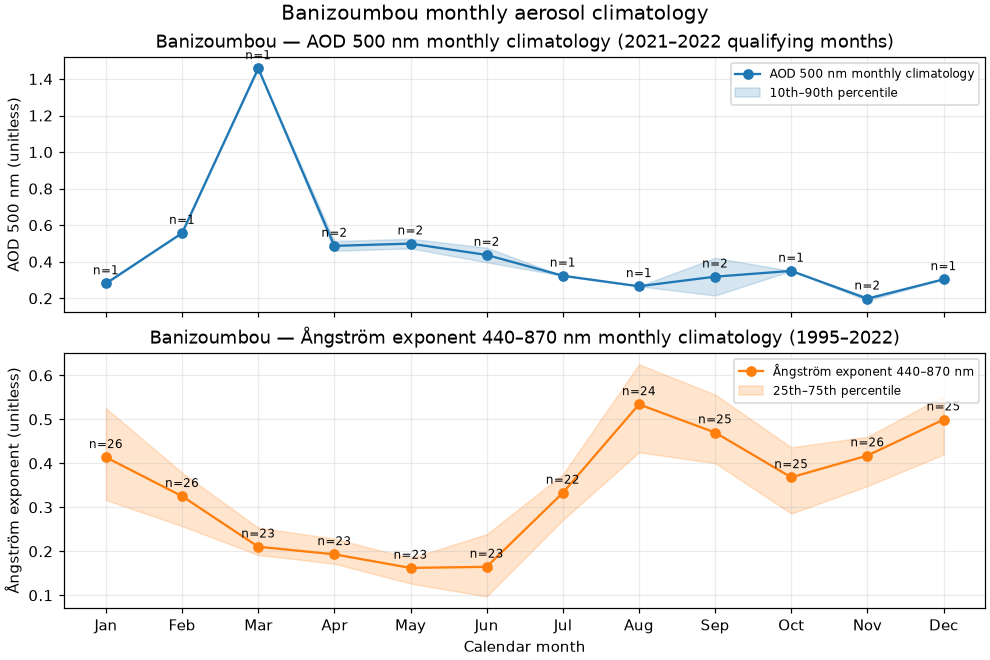


=== KERNEL: kept annual_checked, annual_raw_check | deleted cols, df_ban, month_stats, m, sub, a, ae, row, clim, monthly, clim2, counts, monthly_ok_aod, monthly_ok_ae, chk, av, ev, x, fig, axs, ax, y, lo, hi, xi, yi, n

=== TURN 3 (ok): 8 model calls, 7 tool calls
    in 90304 (uncached 2052, cache read 77876, cache write 10376) | out 5832 (reasoning 1154) | $0.0127
=== CONVERSATION: $0.0308
=== KEPT VARIABLES: 0 | []


In [71]:
r = await ask("monthly climatology of AOD 500 nm and Ångström exponent 440–870 nm at Banizoumbou.")

## Banizoumbou monthly climatology

**Site:** Banizoumbou (13.547°N, 2.665°E; elevation 274 m)  
**Record:** 1995-10-16 to 2022-11-25  
**Wavelengths:** AOD 500 nm and Ångström exponent 440–870 nm, both unitless  
**Method:** AERONET Version 3 Level 2.0 daily means were aggregated to year–month means. A month-year was retained only when it had **at least 5 valid daily values**; the climatology is the mean of those qualifying month-year means. For AOD I also report the median and 10th–90th percentile across qualifying month-year means; for Ångström exponent I report the median and 25th–75th percentile.

| Month | AOD 500 mean | AOD median | AOD 10th–90th pct. | AOD N month-years | AE 440–870 mean | AE median | AE 25th–75th pct. | AE N month-years |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Jan | 0.281 | 0.281 | 0.281–0.281 | 1 | 0.41 | 0.39 | 0.32–0.53 | 26 |
| Feb | 0.557 | 0.557 | 0.557–0.557 | 1 | 0.33 | 0.32 | 0.26–0.38 | 26 |
| Mar | 1.458 | 1.458 | 1.458–1.458 | 1 | 0.21 | 0.20 | 0.19–0.25 | 23 |
| Apr | 0.487 | 0.487 | 0.460–0.514 | 2 | 0.19 | 0.20 | 0.17–0.23 | 23 |
| May | 0.499 | 0.499 | 0.473–0.525 | 2 | 0.16 | 0.15 | 0.13–0.18 | 23 |
| Jun | 0.437 | 0.437 | 0.397–0.477 | 2 | 0.16 | 0.15 | 0.10–0.24 | 23 |
| Jul | 0.323 | 0.323 | 0.323–0.323 | 1 | 0.33 | 0.32 | 0.27–0.37 | 22 |
| Aug | 0.266 | 0.266 | 0.266–0.266 | 1 | 0.53 | 0.49 | 0.43–0.63 | 24 |
| Sep | 0.318 | 0.318 | 0.215–0.421 | 2 | 0.47 | 0.44 | 0.40–0.56 | 25 |
| Oct | 0.350 | 0.350 | 0.350–0.350 | 1 | 0.37 | 0.34 | 0.29–0.44 | 25 |
| Nov | 0.198 | 0.198 | 0.188–0.207 | 2 | 0.42 | 0.43 | 0.35–0.46 | 26 |
| Dec | 0.304 | 0.304 | 0.304–0.304 | 1 | 0.50 | 0.53 | 0.42–0.55 | 25 |

### Coverage and interpretation

- **AOD:** 362 valid daily values over **2021–2022**; 17 qualifying month-years. Thus, the AOD monthly cycle is sparsely sampled and is **not** a robust 28-year climatology. March has the largest available monthly mean (**1.458**), while November has the smallest (**0.198**).
- **Ångström exponent:** 6,581 valid daily values over **1995–2022**; 291 qualifying month-years spanning 22–26 years depending on calendar month. The mean ranges from **0.16 in May** to **0.53 in August**.
- The Ångström exponent was used directly from AERONET’s `Angstrom_Exponent_440_870nm` column, rather than recomputed from daily AODs.
- Missing or screened-out days were not treated as zero. There were 22 instrument identifiers across the record, so long-term monthly comparisons may also reflect instrument changes.

The checked table is saved as `/home/ubuntu/ai_for_aeronet/conversation_data/conv_012/banizoumbou_monthly_climatology_aod500_ae440_870.csv`. The figure is 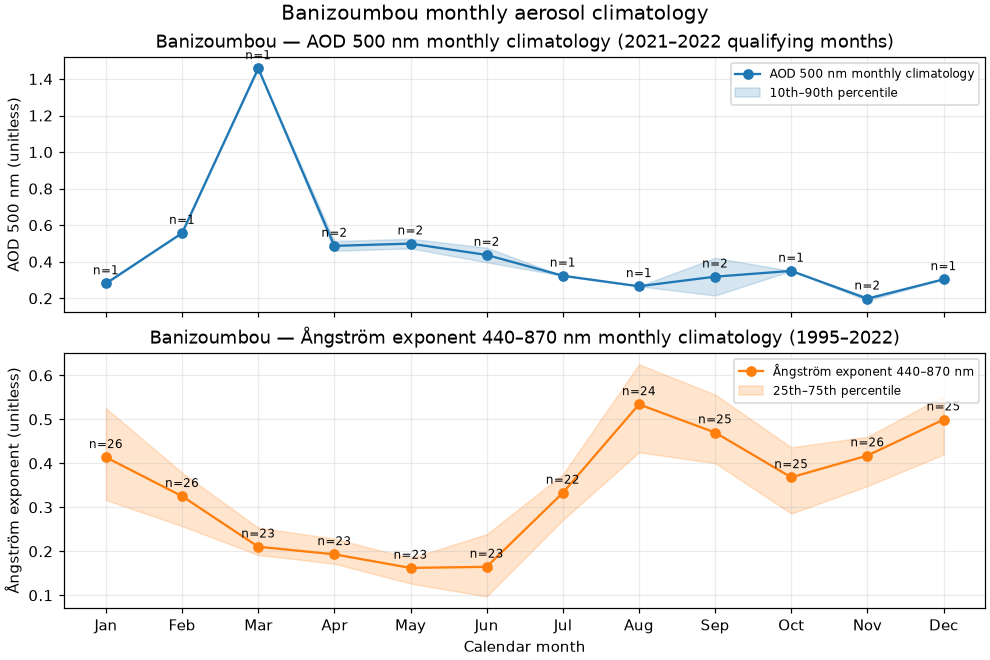.

AERONET site PI: **Jean_Louis_Rajot**.

Checked: monthly climatological means were independently recomputed from the qualifying year–month table; valid-day totals matched direct non-null counts (362 AOD days and 6,581 Ångström-exponent days); values and dates passed physical-range and record-period checks. Figure `banizoumbou_monthly_climatology.png` read-back: the upper panel is AOD 500 nm for 2021–2022 and the lower panel is Ångström exponent 440–870 nm for 1995–2022, with the labeled axes, matching legends, visible N values, AOD maximum 1.458 in March, AOD minimum 0.198 in November, Ångström-exponent maximum 0.53 in August, and minimum 0.16 in May, all matching the table.

In [72]:
answer(r)

In [73]:
sb.state(CONVERSATION_ID)

{'vars': {'annual_checked': 'DataFrame(29, 4)[year, mean_aod_500, n_months, n_daily_values]',
  'annual_raw_check': 'DataFrame(29, 6)[year, mean_aod_500, n_months, n_daily_values, raw_daily_mean, n_raw_days]'},
 'files': ['banizoumbou_monthly_climatology.png',
  'banizoumbou_monthly_climatology_aod500_ae440_870.csv',
  'mauna_loa_annual_aod500.csv'],
 'workspace_mb': 0.13,
 'workspace_cap_mb': 1000,
 'rss_mb': 391,
 'memory_limit_mb': 2147}

In [74]:
variable_meanings()

{'annual_checked': 'Checked Mauna_Loa annual AOD 500 nm table for 1997–2025, monthly-rule annual means, valid months and daily counts',
 'annual_raw_check': 'Independent comparison of checked annual monthly means with direct daily annual means for Mauna_Loa'}

In [75]:
r = await ask("In the Banizoumbou climatology figure, which month has the widest error bar, and what does that mean physically?")

=== In the Banizoumbou climatology figure, which month has the widest error bar, and what does that mean physically?
    (3 earlier turns in context; conversation so far $0.0308)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables (name: type — what it holds):
  annual_checked: DataFrame(29, 4)[year, mean_aod_500, n_months, n_daily_values] — Checked Mauna_Loa annual AOD 500 nm table for 1997–2025, monthly-rule annual means, valid months and daily counts
  annual_raw_check: DataFrame(29, 6)[year, mean_aod_500, n_months, n_daily_values, raw_daily_mean, n_raw_days] — Independent comparison of checked annual monthly means with direct daily annual means for Mauna_Loa
memory used: 391 of 2147 MB; storage used: 0.13 of 1000 MB in /workspace

### question
In the Banizoumbou climatology figure, which month has the widest error bar, and what does that mean physically?
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll inspect the previously saved 

In [76]:
answer(r)

The **September AOD 500 nm** point has the widest shaded band in the upper panel. It represents the **10th–90th percentile spread across qualifying September month-years**, not a measurement error or confidence interval. September’s band is wide because the available AOD climatology contains only **two qualifying month-years**, so it mainly indicates that the sampled September means differed substantially; it is not strong evidence of a stable September physical variability pattern.

Physically, a broad AOD spread means that the aerosol optical loading at 500 nm varied considerably between the sampled Septembers. It could reflect changes in aerosol amount and conditions, but this dataset alone cannot identify the cause.

For completeness, the lower Ångström-exponent panel has its widest band in **January**. That band is the 25th–75th percentile spread across **26 qualifying January month-years** and indicates greater variation in the spectral size characteristic—i.e., changing mixtures of relatively fine and coarse aerosol—from January to January. It does not by itself identify a specific source.

**Site:** Banizoumbou, 13.547°N, 2.665°E, 274 m; record 1995-10-16–2022-11-25. **Products:** AOD 500 nm and Ångström exponent 440–870 nm, both unitless. **Method:** AERONET Version 3 Level 2.0 daily values; month-years required at least 5 valid daily values, then monthly climatological means and percentile bands were calculated. AOD coverage is sparse (362 valid days; only 17 qualifying month-years), whereas the Ångström exponent has 6,581 valid days and 291 qualifying month-years. Missing values were not treated as zero. Site PI acknowledgment: Jean-Louis Rajot.

Checked: site metadata and wavelength availability were confirmed; percentile-band widths were recomputed from the saved climatology table; September was widest for AOD and January for Ångström exponent, matching the figure read-back and the plotted bands.

In [78]:
# put in the PNG name the Banizoumbou answer gave
r = await ask("Look at the banizoumbou climatology figure and tell me one thing you would improve about the figure.")

=== Look at the banizoumbou climatology figure and tell me one thing you would improve about the figure.
    (4 earlier turns in context; conversation so far $0.0364)

--- step 1: to model
  >>> USER        : ### sandbox state now
variables (name: type — what it holds):
  annual_checked: DataFrame(29, 4)[year, mean_aod_500, n_months, n_daily_values] — Checked Mauna_Loa annual AOD 500 nm table for 1997–2025, monthly-rule annual means, valid months and daily counts
  annual_raw_check: DataFrame(29, 6)[year, mean_aod_500, n_months, n_daily_values, raw_daily_mean, n_raw_days] — Independent comparison of checked annual monthly means with direct daily annual means for Mauna_Loa
memory used: 391 of 2147 MB; storage used: 0.13 of 1000 MB in /workspace

### question
Look at the banizoumbou climatology figure and tell me one thing you would improve about the figure.
--- step 1: from model
  ... THINKING    : <no text>
  <<< PREAMBLE    : I’ll re-open the saved Banizoumbou figure and inspect its 

In [79]:
answer(r)

One improvement: **do not connect the AOD monthly points with a continuous line**. The AOD panel is based on only **one or two qualifying month-years per month** (`n=1` or `n=2`), so the line visually suggests a well-established seasonal cycle even though the coverage is extremely sparse. I would use standalone markers, retain the sample-size labels, and add a clear note such as “AOD monthly climatology is sparse; interpret cautiously.”

This applies to **Banizoumbou** (13.547°N, 2.665°E; 274 m), for **AOD 500 nm** and **Ångström exponent 440–870 nm**. The plotted periods are **2021–2022** for AOD and **1995–2022** for Ångström exponent; the latter has much stronger coverage, with roughly 22–26 qualifying month-years per month. Values are AERONET Version 3 Level 2.0 daily means aggregated to qualifying month-years (at least 5 valid daily values per month-year). The site record spans 1995-10-16 to 2022-11-25, with 6,581 days in the site listing. Missing data were not treated as zero.

Checked: the figure was read back; the AOD panel visibly shows `n=1` or `n=2` for every month, while the Ångström-exponent panel has substantially larger and more consistent sample sizes, supporting this improvement.

## 10 · Check the tokens

Every model response in the stored trace carries its own usage. `calls_table(turn)` lists them one call per row and
adds them up; `check_tokens(turn)` compares that sum with the turn's row in the table. They must be equal. When a
later step makes model calls outside the agent loop, this is the check that they were counted. (Looking at figures
happens inside the loop, so it needs no extra accounting.)

Two more columns per call: `images` = how many images were in the model's context for that call (an image stays
in the context for the rest of the question), `image_tokens_est` = their estimated token cost, summed from the
`[image: ..., ≈N tokens]` lines. `input_tokens` already contains them; the estimate only shows their share.

In [37]:
TOKEN_COLUMNS = ["input_tokens", "uncached_input", "cache_read", "cache_write", "output_tokens", "reasoning_tokens"]


def load_messages(turn):
    row = all_turns()[turn - 1]
    return ModelMessagesTypeAdapter.validate_json(row["messages"])


def calls_table(turn):
    """One row per model call of a stored turn, read from its trace, with the images in context at that call."""
    rows = []
    images, image_tokens = 0, 0                             # grow as image lines appear, never shrink within a turn
    for message in load_messages(turn):
        if isinstance(message, ModelRequest):
            for part in message.parts:
                if isinstance(part, ToolReturnPart):
                    for estimate in re.findall(r"\[image: .*?≈(\d+) tokens\]", tool_text(part)):
                        images += 1
                        image_tokens += int(estimate)
        if isinstance(message, ModelResponse):
            columns = token_columns(message.usage)          # same arithmetic as the stored row
            row = {c: columns[c] for c in TOKEN_COLUMNS + ["cost_usd"]}
            row["images"], row["image_tokens_est"] = images, image_tokens
            rows.append(row)
    return pd.DataFrame(rows, index=pd.RangeIndex(1, len(rows) + 1, name="call"))


def check_tokens(turn):
    """Add up the model calls of a stored turn and compare with the numbers in its row."""
    calls  = calls_table(turn)
    stored = all_turns()[turn - 1]
    for c in TOKEN_COLUMNS + ["cost_usd"]:
        summed = sum(v or 0 for v in calls[c])              # None (not reported) counts as 0
        verdict = "ok" if abs(summed - (stored[c] or 0)) < 1e-9 else "MISMATCH"
        print(f"  {c:17} sum of {len(calls)} calls: {summed:>10.6g}   stored: {stored[c]!s:>10}   {verdict}")

In [38]:
calls_table(1)

,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd,images,image_tokens_est
call,,,,,,,,,
1,5595,121,0,5474,142,83,0.001719,0,0
2,6533,121,5474,938,162,17,0.000619,0,0
3,11131,121,6412,4598,416,224,0.001981,0,0
4,11718,121,11010,587,691,148,0.001342,0,0
5,12984,121,11597,1266,417,88,0.001180,0,0
6,13613,121,12863,629,717,101,0.001429,0,0


In [39]:
calls_table(-1)

,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd,images,image_tokens_est
call,,,,,,,,,
1,8303,121,5408,2774,110,44,0.001054,0,0
2,9671,1205,8182,284,1519,760,0.002528,1,804


In [40]:
check_tokens(1)

  input_tokens      sum of 6 calls:      61574   stored:      61574   ok
  uncached_input    sum of 6 calls:        726   stored:        726   ok
  cache_read        sum of 6 calls:      47356   stored:      47356   ok
  cache_write       sum of 6 calls:      13492   stored:      13492   ok
  output_tokens     sum of 6 calls:       2545   stored:       2545   ok
  reasoning_tokens  sum of 6 calls:        661   stored:        661   ok
  cost_usd          sum of 6 calls: 0.00827125   stored: 0.008271252   ok


## 11 · Resume tomorrow

Nothing to save: SQLite already has every turn. After reopening the notebook:

1. Run sections 1–8 with the same `CONVERSATION_ID`. Nothing is loaded into Python: every function reads the
   SQLite file when it is called.
2. `preview_context()` shows what the next question will get: the last `KEEP_TURNS` finished turns from the file,
   and a state block from the sandbox. The container stopped itself after 60 idle minutes, so section 2 starts a
   new one (new id ≠ id of the last turn) and the block says *restarted*, with no variables and the files of the last 5 turns.
3. `await ask(...)` as usual. The model can reload what it needs from the files the earlier answers name.

Same thing as the `sb.stop` in section 9. The only difference is that the notebook itself was closed as well.

In [41]:
show_turns()

,turn,asked,status,question,summary,variables,sandbox,restart_note,requests,tool_calls,input_tokens,uncached_input,cache_read,cache_write,output_tokens,reasoning_tokens,cost_usd
0,1,2026-09-30T16:17:23+00:00,ok,Which five sites have the longest AOD 500 nm r...,"tools: list_sites×1, describe_columns×5, run_p...",[],ec652083a1ff,None,6,9,61574,726,47356,13492,2545,661,0.008271
1,2,2026-09-30T16:18:56+00:00,ok,"For the top one of those, what is its mean AOD...","tools: list_sites×1, describe_columns×1, run_p...","[{""name"": ""annual_ok"", ""meaning"": ""Checked Mau...",ec652083a1ff,None,5,5,44534,605,38041,5888,3326,730,0.006980
2,3,2026-09-30T16:21:22+00:00,ok,monthly climatology of AOD 500 nm and Ångström...,"tools: list_sites×1, describe_columns×1, run_p...",[],ec652083a1ff,None,7,6,70388,1931,60452,8005,4263,810,0.009583
3,4,2026-09-30T16:23:41+00:00,ok,"In the Banizoumbou climatology figure, which m...",tools: view_figure×1,[],ec652083a1ff,None,2,1,17974,1326,13590,3058,1629,804,0.003582
4,5,2026-09-30T16:23:54+00:00,ok,Look at the banizoumbou climatology figure and...,tools: view_figure×1,[],ec652083a1ff,None,2,1,18602,1326,13917,3359,1104,436,0.002979


In [42]:
preview_context()

--- USER : ['Conversation so far:', CachePoint(kind='cache-point', ttl='5m')]

--- USER : Which five sites have the longest AOD 500 nm records, and how many days of data does each have?

--- MODEL: ## Five longest AOD 500 nm records

**Skill used:** data access. I ranked all 1,485 sites by the number of non-missing daily **AOD 500 nm** values (AOD is unitless), rather than by calendar span. Each row is an AERONET Level 2.0 daily mean; missing AOD values were excluded and were not treated as zero.

| Rank | Site | Coordinates (lat, lon) | Elevation (m) | Valid AOD 500 nm period | N (days) |
|---:|---|---:|---:|---|---:|
| 1 | Mauna_Loa | 19.536, −155.577 | 3402 | 1995-03-16 to 2026-07-07 | 9,152 |
| 2 | GSFC | 38.993, −76.840 | 87 | 1995-03-24 to 2026-01-08 | 7,973 |
| 3 | SEDE_BOKER | 30.855, 34.782 | 480 | 1997-09-25 to 2025-04-04 | 7,706 |
| 4 | Izana | 28.309, −16.499 | 2401 | 1997-06-15 to 2026-01-27 | 6,375 |
| 5 | Sevilleta | 34.355, −106.885 | 1477 | 1995-07-06 to 2025-03-26 | 6

In [43]:
# the full trace of one turn, message by message
for message in load_messages(1):
    for p in message.parts:
        show_part(p)

  >>> USER        : ### sandbox state now
variables: none
memory used: 201 of 2147 MB; storage used: 0.0 of 1000 MB in /workspace

### question
Which five sites have the longest AOD 500 nm records, and how many days of data does each have?
  ... THINKING    : <no text>
  <<< ANSWER      : I’ll first identify the longest-record sites and their exact names, coordinates, and record spans, then verify which of those measured AOD at 500 nm.
  --> TOOL CALL   : list_sites({"limit":20})
  <-- TOOL RESULT : list_sites -> 1485 site(s) match, showing the 20 with the longest records
                        lat      lon  elev_m       first        last  days
AERONET_Site_Name                                                         
Mauna_Loa            19.536 -155.577    3402  1994-06-03  2026-07-07  9198
GSFC                 38.992  -76.840      87  1993-05-14  2026-01-08  8234
SEDE_BOKER           30.855   34.782     480  1995-08-11  2025-04-04  7767
Ispra                45.803    8.627     235  

## 12 · Cleanup

In [44]:
sb.stop(CONVERSATION_ID)